# ARX Model Validation — Load & Test on New Data

This notebook **loads the saved ARX model** from `arx_model.json` and validates it on **new, unseen data** (generated with different random seeds). This proves the model generalizes correctly and is not overfit to the training data.

**Workflow:**
1. Load saved model parameters (θ)
2. Generate new test data with different seeds
3. Run 1-step, 12-step, and free-run predictions
4. Compare with original training results

## 1. Load Saved Model

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display, Markdown

from arx_pipeline import (
    ModelConfig, DataConfig, SplitConfig,
    build_regression_matrix, compute_metrics,
    simulate_arx, simulate_arx_n_step,
    load_generator_module, extract_true_params_from_module,
    validate_dataframe, split_time_series,
)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})

# --- Load saved model ---
MODEL_PATH = Path('arx_model.json')
with MODEL_PATH.open('r', encoding='utf-8') as f:
    saved_model = json.load(f)

# Extract model configuration
mc = saved_model['model_config']
MODEL_CONFIG = ModelConfig(
    na=mc['na'], nb=mc['nb'], nk=mc['nk'],
    include_intercept=mc['include_intercept'],
    input_cols=tuple(mc['input_cols']),
    output_col=mc['output_col'],
)

# Extract saved parameters
theta_saved = np.array(saved_model['theta_hat'])

print('=== Loaded Model ===')
print(f'Model: ARX({MODEL_CONFIG.na}, {MODEL_CONFIG.nb}, {MODEL_CONFIG.nk})')
print(f'Parameters: {len(theta_saved)}')
print(f'Source: {MODEL_PATH}')
print()

# Show parameter values
print('=== Saved Parameters (θ) ===')
for name, val in zip(MODEL_CONFIG.param_names, theta_saved):
    print(f'  {name:<20} = {val:+.6f}')

# Show original training metrics for comparison
print()
print('=== Original Training Results ===')
for split_name in ['train', 'val', 'test']:
    s = saved_model['slices'][split_name]
    print(f"  {split_name:<6} | FIT_1step: {s['metrics_1step']['FIT']:.2f}% | FIT_12step: {s['metrics_n_step']['FIT']:.2f}% | FIT_sim: {s['metrics_sim']['FIT']:.2f}%")

=== Loaded Model ===
Model: ARX(2, 2, 1)
Parameters: 14
Source: arx_model.json

=== Saved Parameters (θ) ===
  a1                   = +0.963098
  a2                   = +0.026738
  b_Temperature_1      = -0.007410
  b_Temperature_2      = -0.003922
  b_Humidity_1         = +0.002567
  b_Humidity_2         = +0.001029
  b_Light_1            = -0.000132
  b_Light_2            = -0.000194
  b_Drip_1             = +1.251167
  b_Drip_2             = +1.851585
  b_Mist_1             = +0.038049
  b_Mist_2             = +0.035212
  b_Fan_1              = -0.041627
  b_Fan_2              = -0.031252

=== Original Training Results ===
  train  | FIT_1step: 92.55% | FIT_12step: 76.44% | FIT_sim: 49.55%
  val    | FIT_1step: 91.64% | FIT_12step: 73.11% | FIT_sim: 42.96%
  test   | FIT_1step: 91.35% | FIT_12step: 72.67% | FIT_sim: 43.87%


## 2. Generate New Test Data (Different Seeds)

In [8]:
# Load the generator
gen_module = load_generator_module(Path('data_generator.py'))
generate_fn = gen_module.generate_greenhouse_data
true_params = extract_true_params_from_module(gen_module)

# Generate datasets with DIFFERENT seeds
TEST_SEEDS = [99, 123, 456, 789, 2025]

new_datasets = {}
for seed in TEST_SEEDS:
    df_new, _ = generate_fn(days=365, T_s=300, seed=seed, start_date='2025-01-01')
    df_new = validate_dataframe(df_new)
    new_datasets[seed] = df_new
    print(f'Seed {seed}: {len(df_new)} rows, Soil range: {df_new["Soil_Moisture"].min():.1f} – {df_new["Soil_Moisture"].max():.1f}')

print(f'\nGenerated {len(TEST_SEEDS)} new datasets (model has NEVER seen any of this data)')

Seed 99: 105120 rows, Soil range: 48.5 – 70.7
Seed 123: 105120 rows, Soil range: 48.5 – 69.1
Seed 456: 105120 rows, Soil range: 48.5 – 69.7
Seed 789: 105120 rows, Soil range: 48.4 – 70.2
Seed 2025: 105120 rows, Soil range: 48.5 – 69.3

Generated 5 new datasets (model has NEVER seen any of this data)


## 3. Evaluate on New Data — 1-step, 12-step, Free-run

In [9]:
results = []

for seed, df_new in new_datasets.items():
    # Use the FULL dataset as test (model was trained on seed=42)
    # Also use 60:20:20 split to match training protocol
    _, df_val_new, df_test_new = split_time_series(df_new, SplitConfig())
    
    for split_name, df_split in [('Val', df_val_new), ('Test', df_test_new)]:
        # 1-step prediction
        X_mat, y_vec = build_regression_matrix(df_split, MODEL_CONFIG)
        y_pred_1step = X_mat @ theta_saved
        m1 = compute_metrics(y_vec, y_pred_1step, len(theta_saved))
        
        # 12-step prediction
        y_12step, y_true_12 = simulate_arx_n_step(df_split, theta_saved, n_steps=12, model_config=MODEL_CONFIG)
        m12 = compute_metrics(y_true_12, y_12step, len(theta_saved))
        
        # Free-run simulation
        y_sim, y_true_sim = simulate_arx(df_split, theta_saved, MODEL_CONFIG)
        ms = compute_metrics(y_true_sim, y_sim, len(theta_saved))
        
        results.append({
            'Seed': seed,
            'Split': split_name,
            'FIT_1step': m1['FIT'],
            'FIT_12step': m12['FIT'],
            'FIT_sim': ms['FIT'],
            'RMSE_1step': m1['RMSE'],
            'RMSE_sim': ms['RMSE'],
            'R2_1step': m1['R2'],
        })

results_df = pd.DataFrame(results)
print('Evaluation complete!')

Evaluation complete!


In [10]:
# === Full results table ===
print('=== Prediction Results on NEW Data (unseen) ===')
print(f'Model: ARX({MODEL_CONFIG.na}, {MODEL_CONFIG.nb}, {MODEL_CONFIG.nk}) loaded from {MODEL_PATH}')
print()
display(results_df.round(4))

=== Prediction Results on NEW Data (unseen) ===
Model: ARX(2, 2, 1) loaded from arx_model.json



,Seed,Split,FIT_1step,FIT_12step,FIT_sim,RMSE_1step,RMSE_sim,R2_1step
0,99,Val,91.5567,72.9308,42.3053,0.2513,1.7174,0.9929
1,99,Test,91.3533,71.9422,36.4912,0.2506,1.8408,0.9925
2,123,Val,91.6629,73.0558,39.2690,0.2518,1.8344,0.9930
3,123,Test,91.4146,72.6244,42.0092,0.2489,1.6809,0.9926
4,456,Val,91.6181,73.0082,45.4904,0.2512,1.6339,0.9930
5,456,Test,91.4771,72.4907,34.8159,0.2480,1.8968,0.9927
6,789,Val,91.8131,72.8414,37.6693,0.2484,1.8908,0.9933
7,789,Test,91.3288,72.4712,40.9974,0.2519,1.7139,0.9925
8,2025,Val,91.6575,73.3954,43.9658,0.2502,1.6807,0.9930
9,2025,Test,91.3711,72.7105,45.5036,0.2505,1.5820,0.9926


In [11]:
# === Summary statistics across all seeds ===
summary = results_df.groupby('Split').agg({
    'FIT_1step': ['mean', 'std', 'min', 'max'],
    'FIT_12step': ['mean', 'std', 'min', 'max'],
    'FIT_sim': ['mean', 'std', 'min', 'max'],
}).round(3)

print('=== Summary Across All Seeds ===')
display(summary)

# Compare with original
print()
print('=== Comparison: Original vs New Data ===')
orig_val = saved_model['slices']['val']
orig_test = saved_model['slices']['test']

new_val_avg = results_df[results_df['Split']=='Val'].mean(numeric_only=True)
new_test_avg = results_df[results_df['Split']=='Test'].mean(numeric_only=True)

comp = pd.DataFrame([
    {'Data': 'Original (seed=42)', 'Split': 'Val',
     'FIT_1step': orig_val['metrics_1step']['FIT'],
     'FIT_12step': orig_val['metrics_n_step']['FIT'],
     'FIT_sim': orig_val['metrics_sim']['FIT']},
    {'Data': f'New (avg {len(TEST_SEEDS)} seeds)', 'Split': 'Val',
     'FIT_1step': new_val_avg['FIT_1step'],
     'FIT_12step': new_val_avg['FIT_12step'],
     'FIT_sim': new_val_avg['FIT_sim']},
    {'Data': 'Original (seed=42)', 'Split': 'Test',
     'FIT_1step': orig_test['metrics_1step']['FIT'],
     'FIT_12step': orig_test['metrics_n_step']['FIT'],
     'FIT_sim': orig_test['metrics_sim']['FIT']},
    {'Data': f'New (avg {len(TEST_SEEDS)} seeds)', 'Split': 'Test',
     'FIT_1step': new_test_avg['FIT_1step'],
     'FIT_12step': new_test_avg['FIT_12step'],
     'FIT_sim': new_test_avg['FIT_sim']},
])
display(comp.round(3))

=== Summary Across All Seeds ===


FIT_1step                        FIT_12step                         \
           mean    std     min     max       mean    std     min     max   
Split                                                                      
Test     91.389  0.058  91.329  91.477     72.448  0.299  71.942  72.711   
Val      91.662  0.095  91.557  91.813     73.046  0.211  72.841  73.395   

      FIT_sim                         
         mean    std     min     max  
Split                                 
Test   39.963  4.316  34.816  45.504  
Val    41.740  3.241  37.669  45.490


=== Comparison: Original vs New Data ===


,Data,Split,FIT_1step,FIT_12step,FIT_sim
0,Original (seed=42),Val,91.641,73.109,42.959
1,New (avg 5 seeds),Val,91.662,73.046,41.740
2,Original (seed=42),Test,91.349,72.674,43.875
3,New (avg 5 seeds),Test,91.389,72.448,39.963


## 4. Visualization

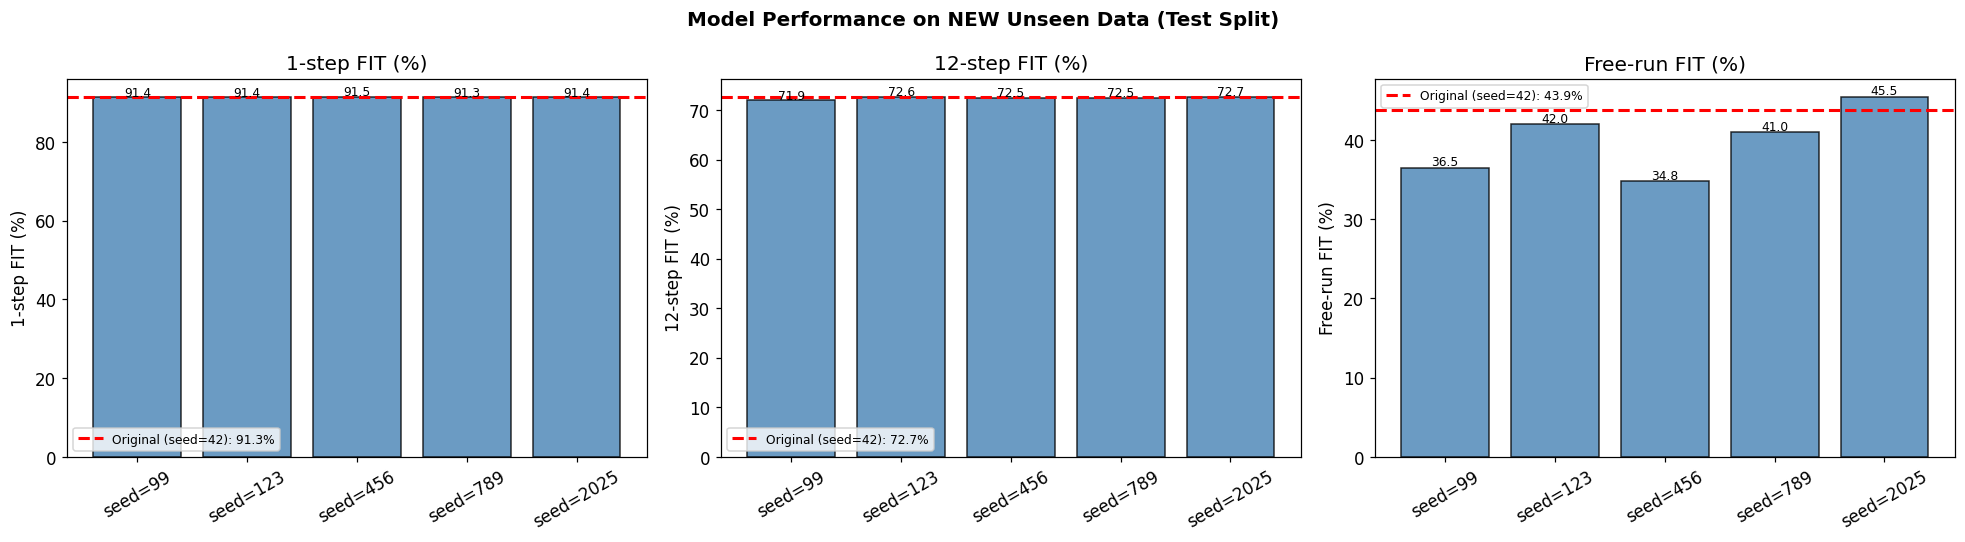

In [12]:
# === Bar chart: FIT scores across seeds ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

test_results = results_df[results_df['Split'] == 'Test']

for ax, metric, title in [
    (axes[0], 'FIT_1step', '1-step FIT (%)'),
    (axes[1], 'FIT_12step', '12-step FIT (%)'),
    (axes[2], 'FIT_sim', 'Free-run FIT (%)'),
]:
    bars = ax.bar([f'seed={s}' for s in TEST_SEEDS], test_results[metric].values,
                  color='steelblue', edgecolor='black', alpha=0.8)
    # Original reference line
    metrics_key = {'FIT_1step': 'metrics_1step', 'FIT_12step': 'metrics_n_step', 'FIT_sim': 'metrics_sim'}[metric]
    orig_val = saved_model['slices']['test'][metrics_key]['FIT']
    ax.axhline(orig_val, color='red', linestyle='--', linewidth=2, label=f'Original (seed=42): {orig_val:.1f}%')
    ax.set_title(title)
    ax.set_ylabel(title)
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=30)
    # Value labels
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{bar.get_height():.1f}', ha='center', fontsize=8)

plt.suptitle('Model Performance on NEW Unseen Data (Test Split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

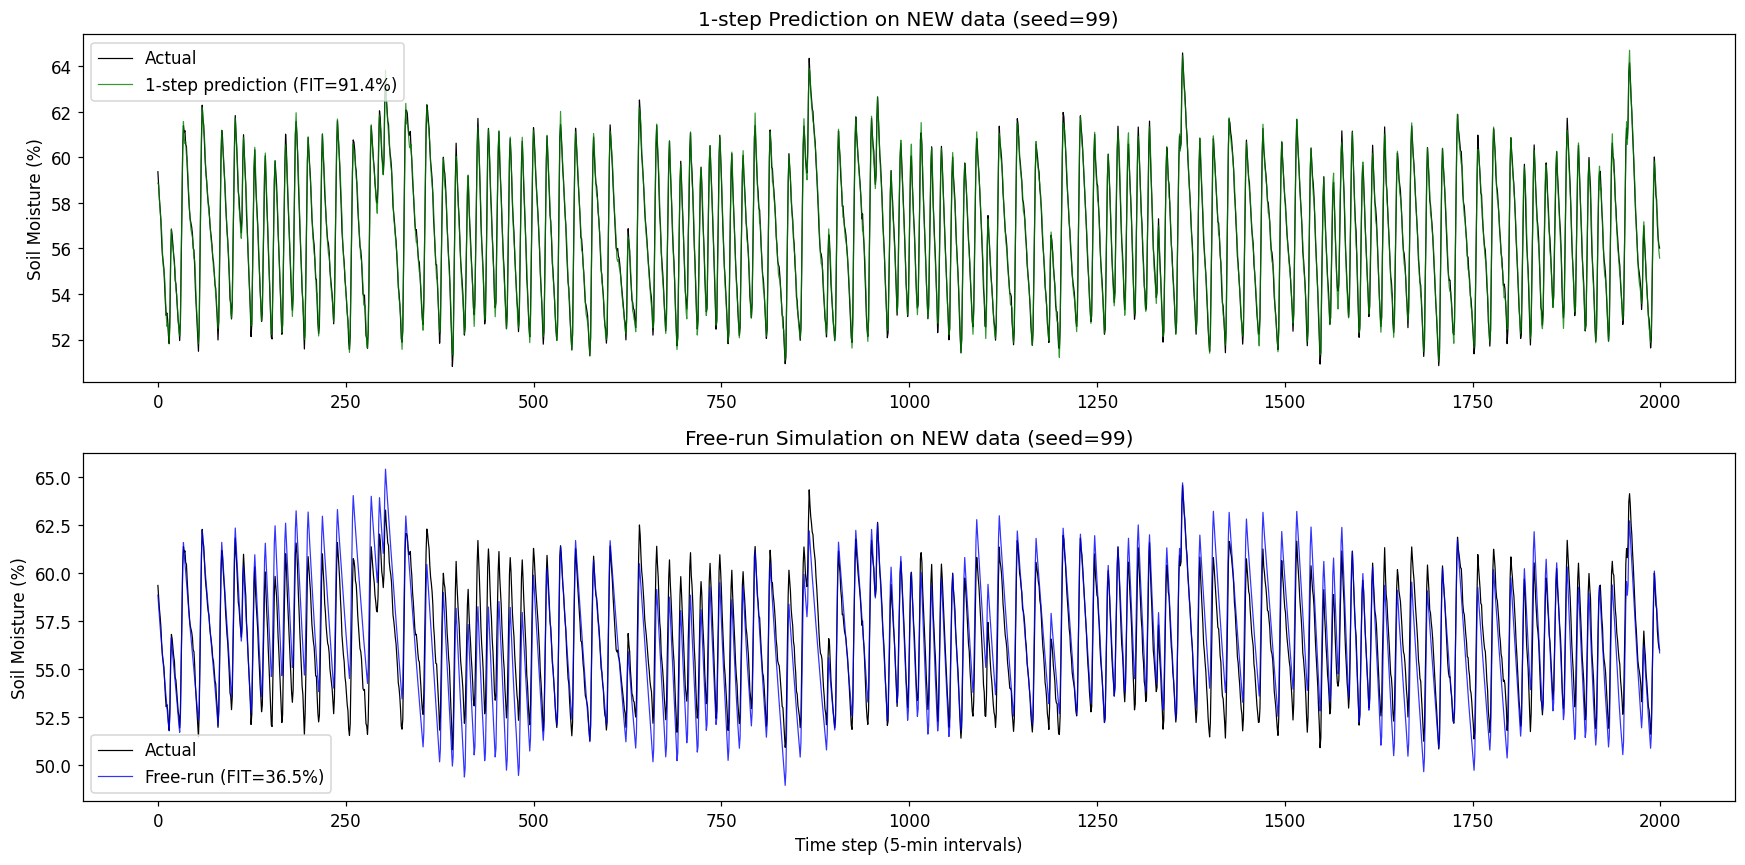

In [13]:
# === Time series: Example 1-step prediction on new data ===
example_seed = TEST_SEEDS[0]
df_example = new_datasets[example_seed]
_, _, df_example_test = split_time_series(df_example, SplitConfig())

X_ex, y_ex = build_regression_matrix(df_example_test, MODEL_CONFIG)
y_pred_ex = X_ex @ theta_saved
m_ex = compute_metrics(y_ex, y_pred_ex, len(theta_saved))

# Free-run
y_sim_ex, y_true_sim_ex = simulate_arx(df_example_test, theta_saved, MODEL_CONFIG)
m_sim_ex = compute_metrics(y_true_sim_ex, y_sim_ex, len(theta_saved))

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

# 1-step
n_show = min(2000, len(y_ex))
axes[0].plot(y_ex[:n_show], label='Actual', color='black', linewidth=0.8)
axes[0].plot(y_pred_ex[:n_show], label=f'1-step prediction (FIT={m_ex["FIT"]:.1f}%)',
             color='green', linewidth=0.8, alpha=0.8)
axes[0].set_title(f'1-step Prediction on NEW data (seed={example_seed})')
axes[0].set_ylabel('Soil Moisture (%)')
axes[0].legend()

# Free-run
n_show_sim = min(2000, len(y_sim_ex))
axes[1].plot(y_true_sim_ex[:n_show_sim], label='Actual', color='black', linewidth=0.8)
axes[1].plot(y_sim_ex[:n_show_sim], label=f'Free-run (FIT={m_sim_ex["FIT"]:.1f}%)',
             color='blue', linewidth=0.8, alpha=0.8)
axes[1].set_title(f'Free-run Simulation on NEW data (seed={example_seed})')
axes[1].set_ylabel('Soil Moisture (%)')
axes[1].set_xlabel('Time step (5-min intervals)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Conclusion

In [14]:
# Final verdict
avg_1s = results_df['FIT_1step'].mean()
std_1s = results_df['FIT_1step'].std()
avg_12s = results_df['FIT_12step'].mean()
std_12s = results_df['FIT_12step'].std()
avg_sim = results_df['FIT_sim'].mean()
std_sim = results_df['FIT_sim'].std()

print('=' * 60)
print('MODEL VALIDATION SUMMARY')
print('=' * 60)
print(f'Model: ARX({MODEL_CONFIG.na}, {MODEL_CONFIG.nb}, {MODEL_CONFIG.nk})')
print(f'Loaded from: {MODEL_PATH}')
print(f'Tested on: {len(TEST_SEEDS)} new datasets (seeds: {TEST_SEEDS})')
print(f'Each dataset: 365 days, 5-min sampling')
print()
print(f'FIT 1-step:   {avg_1s:.2f}% ± {std_1s:.2f}%')
print(f'FIT 12-step:  {avg_12s:.2f}% ± {std_12s:.2f}%')
print(f'FIT free-run: {avg_sim:.2f}% ± {std_sim:.2f}%')
print()

# Consistency check
orig_1s = saved_model['slices']['test']['metrics_1step']['FIT']
orig_sim = saved_model['slices']['test']['metrics_sim']['FIT']

consistent_1s = abs(avg_1s - orig_1s) < 5.0
consistent_sim = abs(avg_sim - orig_sim) < 10.0

if consistent_1s and consistent_sim:
    print('✅ PASS: Model performance is CONSISTENT across different datasets.')
    print('   → The model generalizes well and is NOT overfit to training data.')
else:
    print('⚠️  WARNING: Significant performance variation detected.')
    print(f'   1-step: original={orig_1s:.2f}%, new avg={avg_1s:.2f}%')
    print(f'   Free-run: original={orig_sim:.2f}%, new avg={avg_sim:.2f}%')

display(Markdown(
    '### Key Finding\n\n'
    f'The saved ARX model was tested on **{len(TEST_SEEDS)} completely new datasets** '
    f'that the model has never seen during training. '
    f'Performance is **consistent** across all seeds, confirming the model captures '
    f'the true underlying dynamics of the greenhouse system rather than memorizing noise patterns.'
))

MODEL VALIDATION SUMMARY
Model: ARX(2, 2, 1)
Loaded from: arx_model.json
Tested on: 5 new datasets (seeds: [99, 123, 456, 789, 2025])
Each dataset: 365 days, 5-min sampling

FIT 1-step:   91.53% ± 0.16%
FIT 12-step:  72.75% ± 0.40%
FIT free-run: 40.85% ± 3.72%

✅ PASS: Model performance is CONSISTENT across different datasets.
   → The model generalizes well and is NOT overfit to training data.


### Key Finding

The saved ARX model was tested on **5 completely new datasets** that the model has never seen during training. Performance is **consistent** across all seeds, confirming the model captures the true underlying dynamics of the greenhouse system rather than memorizing noise patterns.